<a href="https://colab.research.google.com/github/Srihitha-M/NASSCOM/blob/main/Use_Case_Detecting_Abnormal_Product_Pricing_in_an_E_Commerce_Platform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Synthetic Dataset Generation
import numpy as np
import pandas as pd

np.random.seed(42)

# 95 normal market prices + 5 overpriced sellers
normal_prices = np.random.normal(loc=25000, scale=3000, size=95)
outlier_prices = np.array([45000, 48000, 50000, 52000, 55000])

data = {"product_price": np.concatenate([normal_prices, outlier_prices])}
df = pd.DataFrame(data)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head().round(2))

Dataset Shape: (100, 1)

First 5 rows:
   product_price
0       26490.14
1       24585.21
2       26943.07
3       29569.09
4       24297.54


In [2]:
# Cell 2: Measures of Central Tendency
mean_price = df["product_price"].mean()
median_price = df["product_price"].median()
mode_price = df["product_price"].mode()[0]

print(f"Mean   : {mean_price:.2f}")
print(f"Median : {median_price:.2f}")
print(f"Mode   : {mode_price:.2f}")

Mean   : 25972.53
Median : 24838.25
Mode   : 17140.76


In [3]:
# Cell 3: Measures of Dispersion
price_range = df["product_price"].max() - df["product_price"].min()
variance = df["product_price"].var()
std_dev = df["product_price"].std()

print(f"Range              : {price_range:.2f}")
print(f"Variance           : {variance:.2f}")
print(f"Standard Deviation : {std_dev:.2f}")

Range              : 37859.24
Variance           : 38503215.45
Standard Deviation : 6205.10


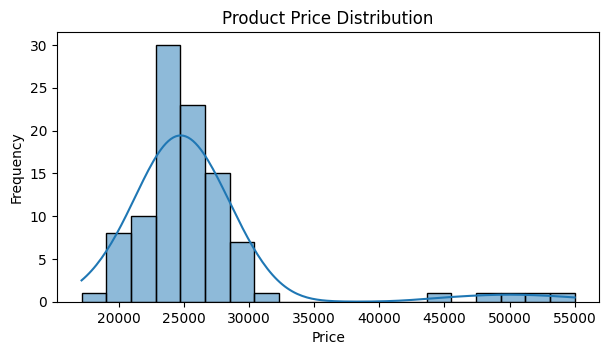

Skewness: 3.033


In [4]:
# Cell 4: Distribution Plot & Skewness
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 3.5))
sns.histplot(df["product_price"], bins=20, kde=True)
plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

skewness = df["product_price"].skew()
print(f"Skewness: {skewness:.3f}")

In [5]:
# Cell 5: Flagging Pricing Anomalies (Gaussian Rule)
lower_bound = mean_price - (2 * std_dev)
upper_bound = mean_price + (2 * std_dev)

df["is_anomalous"] = (df["product_price"] < lower_bound) | (
    df["product_price"] > upper_bound
)
anomalies = df[df["is_anomalous"]]

print(f"Normal Price Band : [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Anomalies Count   : {len(anomalies)}")
print("\nFlagged Prices:")
print(anomalies[["product_price"]].round(2))

Normal Price Band : [13562.34, 38382.73]
Anomalies Count   : 5

Flagged Prices:
    product_price
95        45000.0
96        48000.0
97        50000.0
98        52000.0
99        55000.0


In [6]:
# Cell 6: Covariance & Correlation (Price vs Rating)
np.random.seed(42)

# Generating ratings with penalty for overpriced items (> 35000)
base_rating = np.random.normal(4.2, 0.3, 100)
penalty = (df["product_price"] > 35000) * 1.5
df["rating"] = np.clip(base_rating - penalty, 1.0, 5.0)

cov_matrix = df[["product_price", "rating"]].cov()
corr_matrix = df[["product_price", "rating"]].corr()

print("Covariance Matrix:")
print(cov_matrix.round(4))
print("\nCorrelation Matrix:")
print(corr_matrix.round(4))

Covariance Matrix:
               product_price     rating
product_price   3.850322e+07 -1128.1404
rating         -1.128140e+03     0.1878

Correlation Matrix:
               product_price  rating
product_price         1.0000 -0.4195
rating               -0.4195  1.0000
